# Introduction to Data Science 2026

# Week 3

## Exercise 1 | Working with geospatial data (GIS)

To get at least a bit familiar with [GIS](https://en.wikipedia.org/wiki/Geographic_information_system) data and the concept of map projections, we’ll do a simple task of plotting two data sets that are given in different coordinate systems.

1. Download the [world_m.zip](https://github.com/HY-TKTL/intro-to-data-science-2017/blob/master/world_m.zip) and [cities.zip](https://github.com/HY-TKTL/intro-to-data-science-2017/blob/master/cities.zip) files that each include a set of GIS files. Most notably, the <span style="font-weight: bold">shp</span> files are [Shapefile-files](https://en.wikipedia.org/wiki/Shapefile) with coordinates (don’t look, it’s binary!). The <span style="font-weight: bold">prj</span> files contain information (in plain text, so okay to look) about the coordinate systems. Open the files using your favorite programming environment and packages.  

    <span style="font-weight: 500"> *Hint: We warmly recommend [Geopandas](http://geopandas.org/) for pythonistas.*</span>

In [1]:
import geopandas

cities_gdf = geopandas.read_file("cities/cities.shp")
world_gdf = geopandas.read_file("world_m/world_m.shp")

print(cities_gdf.head())
print(world_gdf.head())

           name                   geometry
0  Vatican City  POINT (12.45339 41.90328)
1    San Marino   POINT (12.44177 43.9361)
2         Vaduz   POINT (9.51667 47.13372)
3    Luxembourg      POINT (6.13 49.61166)
4       Palikir  POINT (158.14997 6.91664)
      pop_est      continent                  name iso_a3  gdp_md_est  \
0  28400000.0           Asia           Afghanistan    AFG     22270.0   
1  12799293.0         Africa                Angola    AGO    110300.0   
2   3639453.0         Europe               Albania    ALB     21810.0   
3   4798491.0           Asia  United Arab Emirates    ARE    184300.0   
4  40913584.0  South America             Argentina    ARG    573900.0   

   gdp_per_ca                                           geometry  
0    0.000784  POLYGON ((6813956.99 4227673.562, 6927484.435 ...  
1    0.008618  MULTIPOLYGON (((1817460.823 -651055.118, 18449...  
2    0.005993  POLYGON ((2292095.859 5110825.73, 2277950.23 5...  
3    0.038408  POLYGON ((5741805.75

2. The <span style="font-weight: bold">world_m</span> file contains borders of almost all countries in the world. Plot the world.

<Axes: >

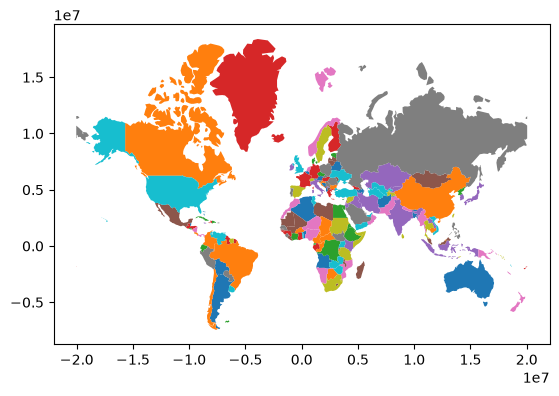

In [2]:
world_gdf.plot("name", legend=False)

3. On top of the countries that you just plotted, plot another layer of information, namely the capital cities of each country from the <span style="font-weight: bold">cities</span> dataset. However, depending on how clever your programming environment is, the cities will probably all appear to be in the Gulf of Guinea, near the coordinates (0°, 0°).

<Axes: >

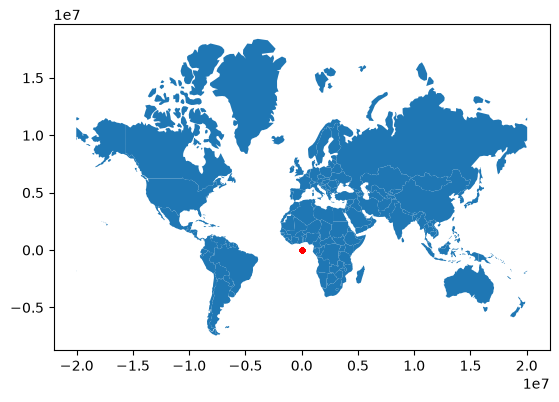

In [3]:
cities_gdf.plot(ax=world_gdf.plot(), color="red", markersize=10, label="Cities")

4. Perform a map projection to bring the two data-sets into a shared coordinate system. (You can choose which one.) Now plot the two layers together to make sure the capital cities are where they are supposed to be.

<Axes: >

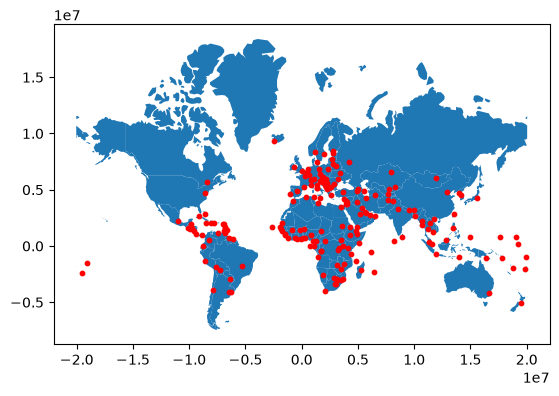

In [4]:
cities_gdf_2 = cities_gdf.to_crs(world_gdf.crs)

ax = world_gdf.plot()
cities_gdf_2.plot(ax=ax, color="red", markersize=10, label="Cities")

**Remember to submit your code on the MOOC platform. You can return this Jupyter notebook (.ipynb) or .py, .R, etc depending on your programming preferences.**

## Exercise 2 | Symbol classification

We’ll be looking into machine learning by checking out the [HASYv2](https://zenodo.org/record/259444#.Wb7efZ8xDhZ) dataset that contains hand written mathematical symbols as images. The whole dataset is quite big, so we’ll restrict ourselves to doing 10-class classification on some of the symbols. Download the data and complete the following tasks.

1. Extract the data and find inside a file called <span style="font-weight: bold">hasy-data-labels.csv</span>. This file contains the labels for each of the images in the <span style="font-weight: bold">hasy_data</span> folder. Read the labels in and only keep the rows where the <span style="font-weight: bold">symbol_id</span> is within the inclusive range <span style="font-weight: bold">[70, 79]</span>. Read the corresponding images as black-and-white images and flatten them so that each image is a single vector of shape <span style="font-weight: bold">32x32 = 1024</span>. Your dataset should now consist of your input data of shape <span style="font-weight: bold">(1020, 1024)</span> and your labels of shape <span style="font-weight: bold">(1020, )</span>. That is, a matrix of shape <span style="font-weight: bold">1020 x 1024</span> and a vector of size <span style="font-weight: bold">1020</span>.

In [5]:
import pandas as pd 
from PIL import Image
import numpy as np

images = []

HASY_labels = pd.read_csv("HASYv2/hasy-data-labels.csv") 

HASY_labels = HASY_labels[(HASY_labels.symbol_id >= 70) & (HASY_labels.symbol_id <= 79)]

print(HASY_labels.head(), HASY_labels.shape)

for image_path in HASY_labels["path"]:
    with Image.open(f"HASYv2/{image_path}") as img:
        img = img.convert("L")
        img = img.resize((32, 32))
        vector = np.asarray(img, dtype=np.float32).flatten()
        vector /= 255.0
        images.append(vector)

dataset = np.array(images, dtype=np.float32)

print(dataset.shape)


                       path  symbol_id latex  user_id
345  hasy-data/v2-00345.png         70     0       10
346  hasy-data/v2-00346.png         70     0       31
347  hasy-data/v2-00347.png         70     0       10
348  hasy-data/v2-00348.png         70     0       10
349  hasy-data/v2-00349.png         70     0       10 (1020, 4)
(1020, 1024)


2. Randomly shuffle the data, and then split it into training and test sets, using the first 80% of the data for training and the rest for evaluation.

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    dataset,
    HASY_labels.latex,
    test_size=0.2,
    random_state=42,
    stratify=HASY_labels.latex
)

3. Fit a logistic regression classifier on the data. Note that we have a multi-class classification problem, but logistic regression is a binary classifier. For this reason, you will find useful <span style="font-weight: bold">[Sklearn's "multi_class" attribute](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html)</span>. Use a multinomial loss and the softmax function to predict the probability of each class as the outcome.  The classifier should select the class with the highest probability. Most library implementations will do this for you - feel free to use one.

In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

model = LogisticRegression(
    solver="lbfgs",
    max_iter=1000
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

probabilities = model.predict_proba(X_test)

print("Classes:", model.classes_)
print("Probability-array shape:", probabilities.shape)

Accuracy: 0.8823529411764706
              precision    recall  f1-score   support

           0       0.96      0.88      0.92        26
           1       0.85      0.92      0.88        24
           2       0.88      0.92      0.90        25
           3       0.92      0.96      0.94        24
           4       0.71      0.83      0.77        12
           5       0.85      0.69      0.76        16
           6       0.90      0.95      0.93        20
           7       0.93      0.87      0.90        15
           8       0.95      0.83      0.89        24
           9       0.80      0.89      0.84        18

    accuracy                           0.88       204
   macro avg       0.88      0.87      0.87       204
weighted avg       0.89      0.88      0.88       204

Classes: ['0' '1' '2' '3' '4' '5' '6' '7' '8' '9']
Probability-array shape: (204, 10)


4. In order to evaluate the model, let’s create our own dummy classifier that simply guesses the most common class in the training set (looking at the test set here would be cheating!). Then, evaluate your logistic regression model on the test data, and compare it to the majority class classifier. The logistic regression model should have significantly better accuracy as the dummy model is merely making a guess.

    <span style="font-weight: 500"> *Hint: Sklearn's DummyClassifier( ) might save you a bit of time.*</span>

In [12]:
from sklearn.dummy import DummyClassifier

dummy_model = DummyClassifier(strategy="most_frequent")
dummy_model.fit(X_train, y_train)
y_dummy_pred = dummy_model.predict(X_test)

print("Dummy Accuracy:", accuracy_score(y_test, y_dummy_pred))
print(classification_report(y_test, y_dummy_pred))

Dummy Accuracy: 0.12745098039215685
              precision    recall  f1-score   support

           0       0.13      1.00      0.23        26
           1       0.00      0.00      0.00        24
           2       0.00      0.00      0.00        25
           3       0.00      0.00      0.00        24
           4       0.00      0.00      0.00        12
           5       0.00      0.00      0.00        16
           6       0.00      0.00      0.00        20
           7       0.00      0.00      0.00        15
           8       0.00      0.00      0.00        24
           9       0.00      0.00      0.00        18

    accuracy                           0.13       204
   macro avg       0.01      0.10      0.02       204
weighted avg       0.02      0.13      0.03       204



/Users/harrigavert/Documents/University/data_science_course/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/harrigavert/Documents/University/data_science_course/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/harrigavert/Documents/University/data_science_course/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `

5. Plot some of the images that the logistic classifier misclassified. Can you think of an explanation why they were misclassified? Would you have gotten them right?
    
    <span style="font-weight: 500">*Hint: Matplotlib has a [function](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.imshow.html) that can help you with plotting.*</span>

Here are some examples of the syntax used to fit a logistic regression classifier (using Sklearn or statsmodel with Python, or GLM with R):

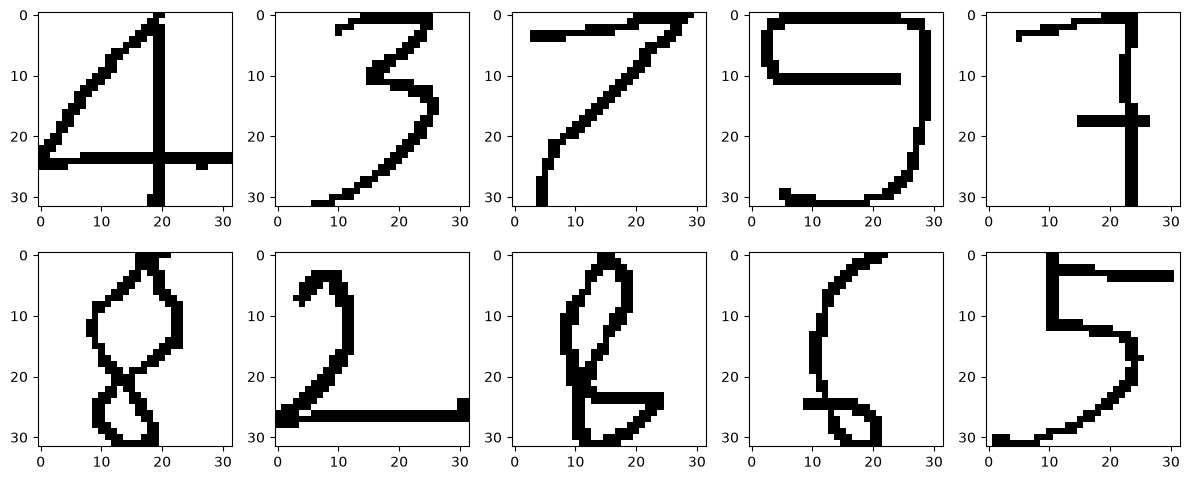

Answer: For some of the images, I can understand the misclassification, as they are pretty far from their original symbol and closer to another symbol. But some of them seem very obvious. I would not make such mistakes, but I'm far more used to varying characteristics when it comes to symbols.


In [16]:
import matplotlib.pyplot as plt

y_test_arr = np.asarray(y_test)
y_pred_arr = np.asarray(y_pred)
X_test_arr = np.asarray(X_test)

misclassified_indices = np.where(y_test_arr != y_pred_arr)[0]

n_show = 10  
plt.figure(figsize=(12, 5))

for i in range(n_show):
    idx = misclassified_indices[i]
    
    image = X_test_arr[idx].reshape(32, 32)
    true_label = y_test_arr[idx]
    predicted_label = y_pred_arr[idx]
    
    plt.subplot(2, 5, i + 1)
    plt.imshow(image, cmap="gray")

plt.tight_layout()
plt.show()

print("Answer: For some of the images, I can understand the misclassification, as they are pretty far from their original symbol and closer to another symbol. But some of them seem very obvious. I would not make such mistakes, but I'm far more used to varying characteristics when it comes to symbols.")

**Remember to submit your code on the MOOC platform. You can return this Jupyter notebook (.ipynb) or .py, .R, etc depending on your programming preferences.**